## Generating Digit Images with a Variational Autoencoder


<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<a href="https://colab.research.google.com/github/DeepTrackAI/DeepLearningCrashCourse/blob/main/Ch04_AE/ec04_A_vae_mnist/vae_mnist.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>
<strong>If using Colab/Kaggle:</strong> You need to uncomment the code in the cell below this one.
</div>

In [22]:
# !pip install deeplay deeptrack  # Uncomment if using Colab/Kaggle.

This notebook provides you with a complete code example that
trains a variational autoencoder on the MNIST digits and uses it to generated
new digit images and cluster the digits in the latent space.

<div style="background-color: #f0f8ff; border: 2px solid #4682b4; padding: 10px;">
<strong>Note:</strong> This notebook contains the Code Example 4-A from the book  

**Deep Learning Crash Course**  
Giovanni Volpe, Benjamin Midtvedt, Jesús Pineda, Henrik Klein Moberg, Harshith Bachimanchi, Joana B. Pereira, Carlo Manzo  
No Starch Press, San Francisco (CA), 2026  
ISBN-13: 9781718503922  

[https://nostarch.com/deep-learning-crash-course](https://nostarch.com/deep-learning-crash-course)

You can find the other notebooks on the [Deep Learning Crash Course GitHub page](https://github.com/DeepTrackAI/DeepLearningCrashCourse).
</div>

In [23]:
import pandas as pd
import os
import deeptrack as dt
import torch
import torch
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
from torchvision.transforms import Compose, Resize, ToTensor
from torchvision.transforms.v2 import Transform
from torch.utils.data import Dataset



data_dir = os.path.join(".", "data")
ann_path = os.path.join(data_dir, "annotations", "list.txt")
im_path = os.path.join(data_dir, "images")

annotations = pd.read_csv(ann_path, sep=" ", header=None, names=["Image", "ID", "SPECIES", "BREED ID"], skiprows=6)

print(f"Number of images: {len(annotations)}")
# print(annotations.iloc[0])
# print(annotations["Image"][0:5])

files = [os.path.join(im_path, f"{annotations['Image'][i]}.jpg") for i in range(len(annotations))]
# print(paths[10])

# files = dt.sources.ImageFolder(root=im_path)

# paths = files._paths

# print(paths[0:2])
# files = dt.sources.Join(files)
# print(files.path[0:5])
# train_files, test_files = torch.utils.data.random_split(files, [0.8, 0.2])
# print(f"Number of train images: {len(train_files)}")
# print(f"Number of test images: {len(test_files)}")

# train_dataloader = torch.utils.data.DataLoader(train_files, batch_size=64, shuffle=True)
# test_dataloader = torch.utils.data.DataLoader(test_files, batch_size=64, shuffle=False)

Number of images: 7349


... create an image pipeline.

In [24]:
import skimage


class NormalizeMinMax(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        image = (image - torch.min(image)) / (torch.max(image) - torch.min(image))
        return torch.tensor(image, dtype=torch.float)


class Grayscale(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        # print(image.shape)
        image = image.permute(1, 2, 0)
        if image.shape[2] != 3:
            image = image[:, :, :3]

        image = skimage.color.rgb2gray(image)
        image = image.reshape(1, image.shape[0], image.shape[1])
        return torch.tensor(image, dtype=torch.float)
    
    
class SquarePad(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):    
        h, w = image.shape[1], image.shape[2]
        if h == w:
            return image
        elif h > w:
            pad = (h - w) // 2
            padded_image = np.pad(image, ((0, 0), (0, 0), (pad, pad)), mode="linear_ramp", end_values=0)
        else:
            pad = (w - h) // 2
            padded_image = np.pad(image, ((0, 0), (pad, pad), (0, 0)), mode="linear_ramp", end_values=0)
        return torch.tensor(padded_image, dtype=torch.float)
    
class SquareCrop(Transform):
    def __init__(self):
        super().__init__()

    def transform(self, image, *args):
        h, w =image.size
        print()
        print(h, w)

        if h > w:
            if (h-w)%2==0:
                image = image.crop((0, (h-w)//2, w, h-((h-w)//2)))
            else:
                image = image.crop((0, (h-w)//2-1, w, h-((h-w)//2)))
        else:
            if (h-w)%2==0:
                image = image.crop(((w-h)//2, 0, w-((w-h)//2), h))
            else:
                image = image.crop(((w-h)//2-1, 0, w-((w-h)//2), h))
        print(image.size)
        return image




In [25]:
from PIL import Image

# image_pip = (LoadImage() >> Grayscale() >> SquarePad() >> Resize((256, 256)) >> dt.NormalizeMinMax()
#              >> dt.MoveAxis(2, 0) >> dt.pytorch.ToTensor(dtype=torch.float))



class AnimalDataset(Dataset):
    def __init__(self,  img_dir, img_labels,
                 transform=Compose([
                        # SquareCrop(),
                        ToTensor(),
                        Grayscale(),
                        Resize((128, 128)),
                        NormalizeMinMax(),
                ]), 
                loader=Image.open):
        self.img_labels = img_labels
        self.img_dir = img_dir
        self.transform = transform
        self.loader = loader
        self.img_size = (128, 128)

    def __len__(self):
        return len(self.img_labels)

    def __getitem__(self, idx):
        img_path = os.path.join(self.img_dir, str(self.img_labels.iloc[idx]) + ".jpg")
        image = self.loader(img_path)
        image = self.transform(image)
        # print(image.shape, self.img_labels[idx])
        return image, image




# %% Load data
dataset = AnimalDataset(
    img_dir=im_path,
    img_labels=annotations['Image'],
)

f = os.path.join(dataset.img_dir, str(dataset.img_labels.iloc[0])+".jpg")


print(dataset[0][0].shape)  
# print(dataset[0].shape)  


torch.Size([1, 128, 128])


C:\Users\jojac\AppData\Local\Temp\ipykernel_3412\3725962865.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


Image shape: torch.Size([1, 128, 128])


C:\Users\jojac\AppData\Local\Temp\ipykernel_3412\3725962865.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


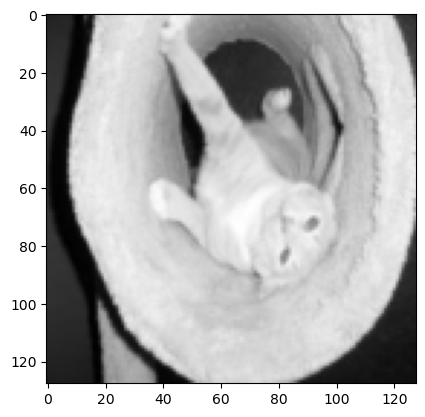

In [26]:
import matplotlib.pyplot as plt
import cv2


for i in range(1):
    img, _ = dataset[np.random.randint(len(dataset))]
    print(f"Image shape: {img.shape}")

    plt.imshow(img.permute(1, 2, 0), cmap="gray")
    plt.show()


## Training the Variational Autoencoder

Define the variational autoencoder ...

In [27]:
import deeplay as dl

# vae = dl.VariationalAutoEncoder(
#     input_size=dataset.img_size, latent_dim=50, channels=[32, 64],
#     reconstruction_loss=torch.nn.BCELoss(reduction="sum"), beta=1,
# ).create()

vae = dl.WassersteinAutoEncoder(
    input_size=dataset.img_size, channels=[128, 128], latent_dim=50,
    reconstruction_loss=torch.nn.MSELoss(reduction="mean"),
).create()

print(vae)

WassersteinAutoEncoder(
  (encoder): ConvolutionalEncoder2d(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): Conv2d(1, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
        (activation): ReLU()
        (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
      (1): Conv2dBlock(
        (layer): Conv2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
        (activation): Identity()
        (normalization): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      )
    )
    (postprocess): Flatten(start_dim=1, end_dim=-1)
  )
  (fc_enc): Linear(in_features=524288, out_features=50, bias=True)
  (fc_dec): Linear(in_features=50, out_features=524288, bias=True)
  (decoder): ConvolutionalDecoder2d(
    (blocks): LayerList(
      (0): Conv2dBlock(
        (layer): ConvTranspose2d(128, 128, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1), output_padding=(1, 1))
        (

... define the train dataset and data loader ...

In [28]:
# train_dataset = dt.pytorch.Dataset(image_pip & image_pip, inputs=train_files)
train_dataset, test_dataset = torch.utils.data.random_split(dataset, [0.8, 0.2])

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=64, shuffle=False)

print(f"Number of train images: {len(train_dataset)}")
print(f"Number of test images: {len(test_dataset)}")


Number of train images: 5880
Number of test images: 1469


... and train the variational autoencoder ...

In [29]:
vae_trainer = dl.Trainer(max_epochs=50, accelerator="auto")
vae_trainer.fit(vae, train_loader)

┏━━━┳━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━┳━━━━━━━┳━━━━━━━┓
┃   ┃ Name                ┃ Type                   ┃ Params ┃ Mode  ┃ FLOPs ┃
┡━━━╇━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━╇━━━━━━━╇━━━━━━━┩
│ 0 │ encoder             │ ConvolutionalEncoder2d │  149 K │ train │     0 │
│ 1 │ fc_enc              │ Linear                 │ 26.2 M │ train │     0 │
│ 2 │ fc_dec              │ Linear                 │ 26.7 M │ train │     0 │
│ 3 │ decoder             │ ConvolutionalDecoder2d │  148 K │ train │     0 │
│ 4 │ reconstruction_loss │ MSELoss                │      0 │ train │     0 │
│ 5 │ train_metrics       │ MetricCollection       │      0 │ train │     0 │
│ 6 │ val_metrics         │ MetricCollection       │      0 │ train │     0 │
│ 7 │ test_metrics        │ MetricCollection       │      0 │ train │     0 │
│ 8 │ optimizer           │ Adam                   │      0 │ train │     0 │
└───┴─────────────────────┴────────────────────────┴────────┴───────┴───────┘

Trainable params: 53.3 M                                                                                           
Non-trainable params: 0                                                                                            
Total params: 53.3 M                                                                                               
Total estimated model params size (MB): 213                                                                        
Modules in train mode: 28                                                                                          
Modules in eval mode: 0                                                                                            
Total FLOPs: 0

Epoch 0:   0%|          | 0/92 [00:00<?, ?it/s]

C:\Users\jojac\AppData\Local\Temp\ipykernel_3412\3725962865.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


Epoch 49: 100%|██████████| 92/92 [03:18<00:00,  0.46it/s, v_num=72, train_rec_loss_step=0.00881, train_mmd_loss_step=0.503, train_rec_loss_epoch=0.00786, train_mmd_loss_epoch=0.506]


torch.Size([1, 128, 128])


C:\Users\jojac\AppData\Local\Temp\ipykernel_3412\3725962865.py:10: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  return torch.tensor(image, dtype=torch.float)


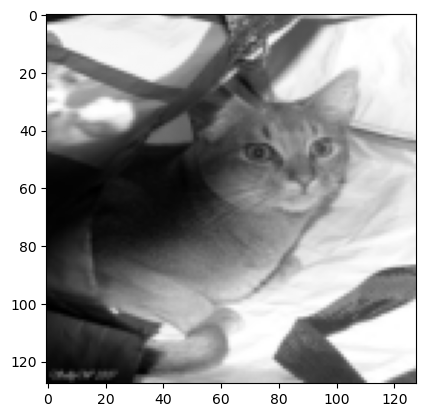

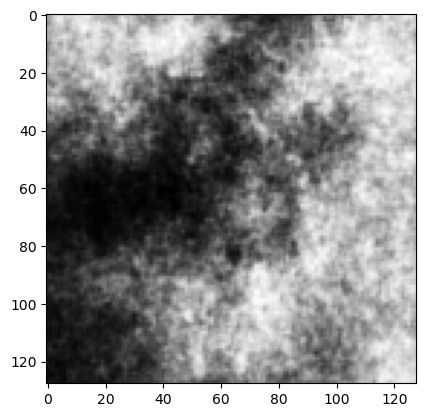

torch.Size([1, 128, 128])


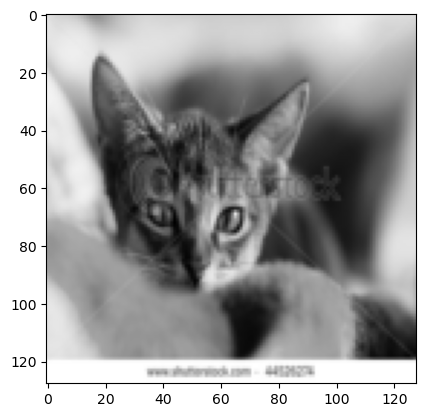

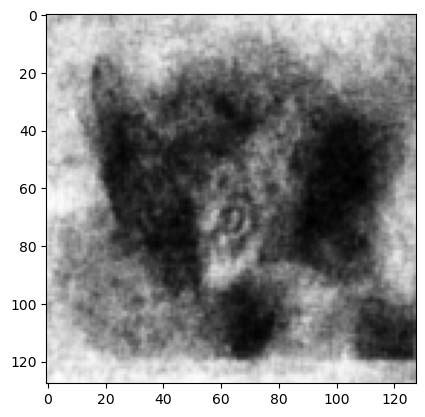

torch.Size([1, 128, 128])


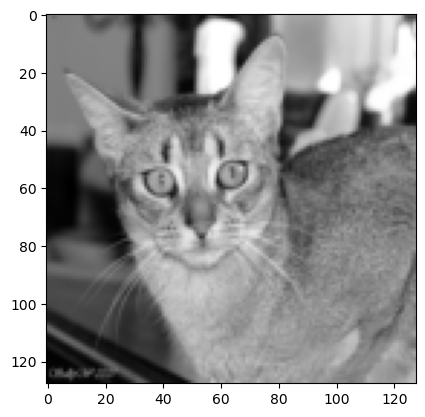

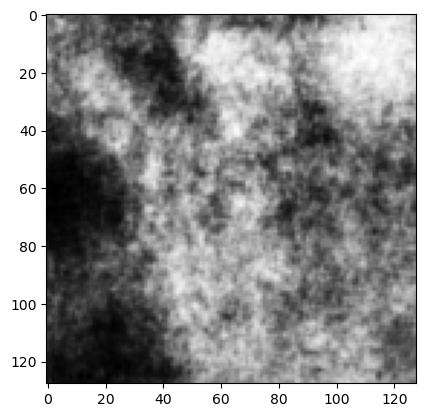

torch.Size([1, 128, 128])


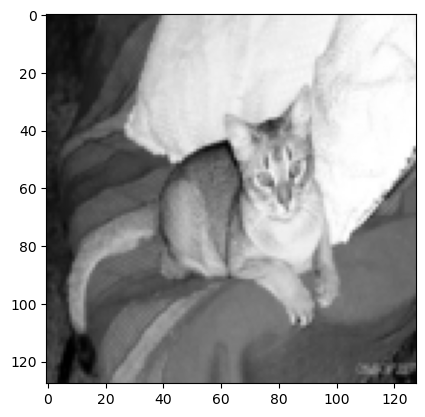

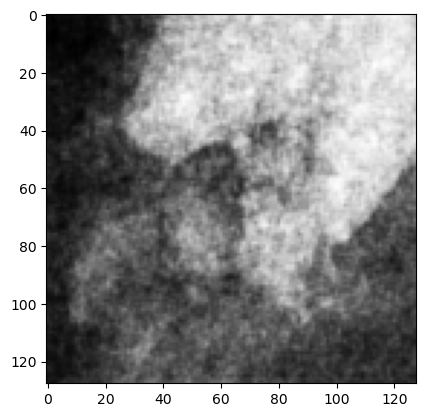

torch.Size([1, 128, 128])


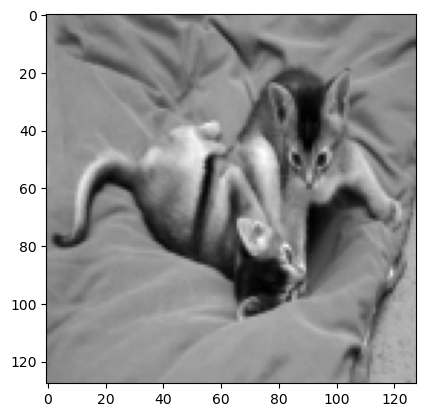

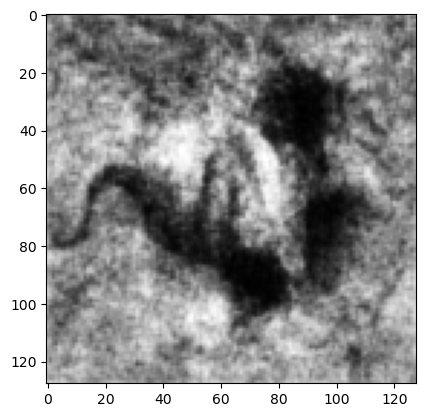

In [30]:
for i in range(5):
    img, _ = dataset[i]
    print(img.shape)
    out = vae(img.unsqueeze(0))[0].squeeze().detach().numpy()
    plt.imshow(img.squeeze(), cmap="gray")
    plt.show()

    plt.imshow(out, cmap="gray")
    plt.show()

## Generating Digit Images with the Decoder

In [31]:
import numpy as np
import matplotlib.pyplot as plt
from torch.distributions.normal import Normal

img_num, img_size = 21, dataset.img_size[0]
z0_grid = z1_grid = Normal(0, 1).icdf(torch.linspace(0.001, 0.999, img_num))

image = np.zeros((img_num * img_size, img_num * img_size))
for i0, z0 in enumerate(z0_grid):
    for i1, z1 in enumerate(z1_grid):
      z = torch.stack((z0, z1)).unsqueeze(0)
      generated_image = vae.decode(z).clone().detach()
      image[i1 * img_size : (i1 + 1) * img_size,
            i0 * img_size : (i0 + 1) * img_size] = \
          generated_image.numpy().squeeze()

plt.figure(figsize=(10, 10))
plt.imshow(image, cmap="gray")
plt.xlabel("z0", fontsize=24)
plt.xticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
           np.round(z0_grid.numpy(), 1))
plt.ylabel("z1", fontsize=24)
plt.yticks(np.arange(0.5 * img_size, (0.5 + img_num) * img_size, img_size),
           np.round(z1_grid.numpy(), 1))
plt.show()

RuntimeError: mat1 and mat2 shapes cannot be multiplied (1x2 and 50x524288)

## Clustering the Digit Images in the Latent Space with the Encoder

Define a pipeline combining the test images and their digit values (labels) ...

In [ ]:
label_pip = dt.Value(files.label_name[0]) >> int
test_dataset = dt.pytorch.Dataset(image_pip & label_pip, inputs=test_files)
test_loader = dl.DataLoader(test_dataset, batch_size=64, shuffle=False)

... encode the test images in the latent space ...

In [ ]:
mu_list, test_labels = [], []
for image, label in test_loader:
    mu, _ = vae.encode(image)
    mu_list.append(mu)
    test_labels.append(label)
mu_array = torch.cat(mu_list, dim=0).detach().numpy()
test_labels = torch.cat(test_labels, dim=0).numpy()

... plot the latent space.

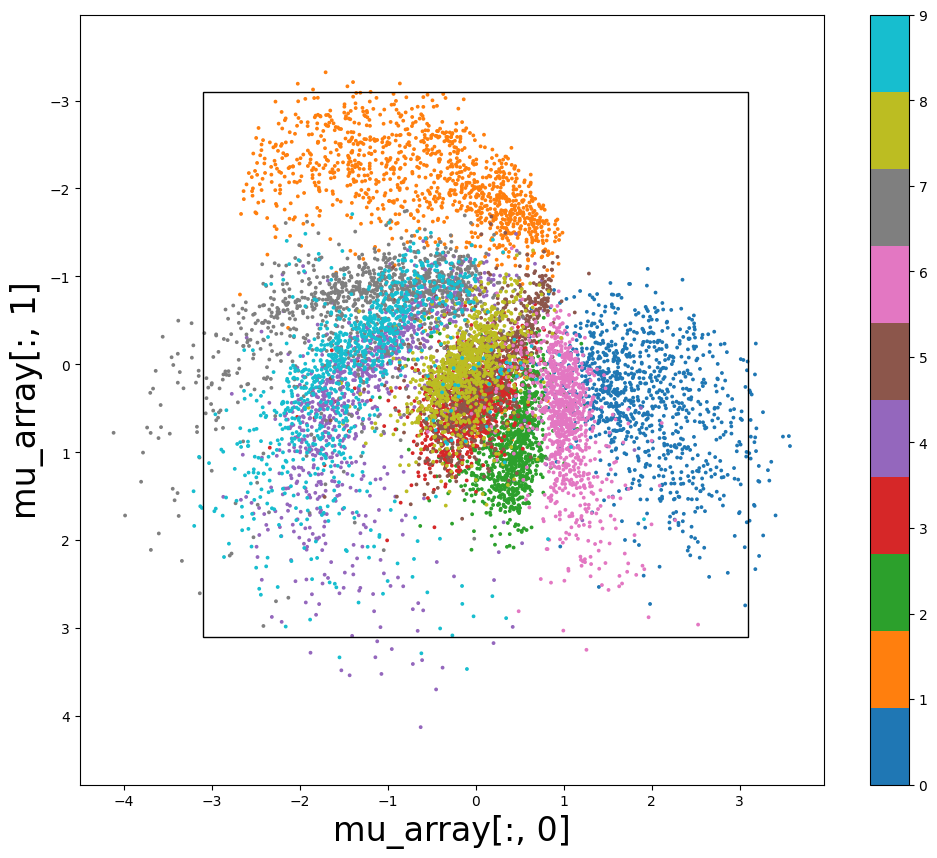

In [ ]:
from matplotlib.patches import Rectangle

plt.figure(figsize=(12, 10))
plt.scatter(mu_array[:, 0], mu_array[:, 1], s=3, c=test_labels, cmap="tab10")
plt.gca().add_patch(Rectangle((-3.1, -3.1), 6.2, 6.2, fc="none", ec="k", lw=1))
plt.xlabel("mu_array[:, 0]", fontsize=24)
plt.ylabel("mu_array[:, 1]", fontsize=24)
plt.gca().invert_yaxis()
plt.axis("equal")
plt.colorbar()
plt.show()